In [1]:
print((268+242+306)/3)

272.0


In [2]:
import numpy as np
import torch
import pandas as pd
import os
import matplotlib.pyplot as plt
import random
import warnings

warnings.filterwarnings("ignore")

# Set the working directory to the project root directly
# Since this notebook is in scripts/, go to the parent directory
project_root = r'c:\Users\Timothee Delcourt\Documents\ETHZ-PhD\Coding\mars_currents_pinn'
os.chdir(project_root)
print("Project root directory:", os.getcwd())

import scripts.utils as ut
import cmcrameri.cm as cmc

import scripts.data_conversion as dc

Project root directory: c:\Users\Timothee Delcourt\Documents\ETHZ-PhD\Coding\mars_currents_pinn


In [5]:
print(np.arctan(20))
print(np.arctan2(20,1))

1.5208379310729538
1.5208379310729538


In [2]:
print(np.sqrt(2*(2500**2)))

3535.5339059327375


Text(0, 0.5, 'dp')

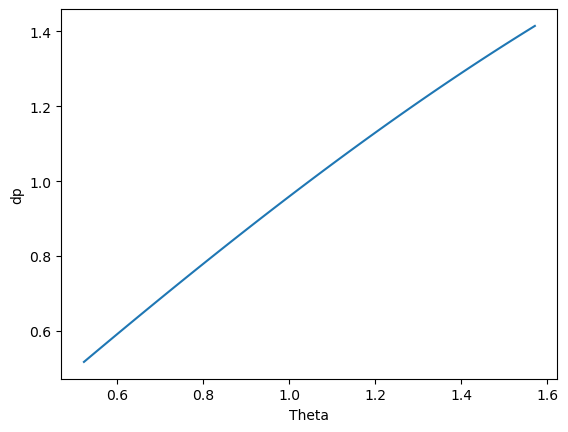

In [5]:
theta = np.linspace(np.pi/6, np.pi/2, 100)
dp = 2*np.sin(theta/2)
plt.plot(theta, dp)
plt.xlabel('Theta')
plt.ylabel('dp')

In [3]:
print(np.random.choice([3]))

3


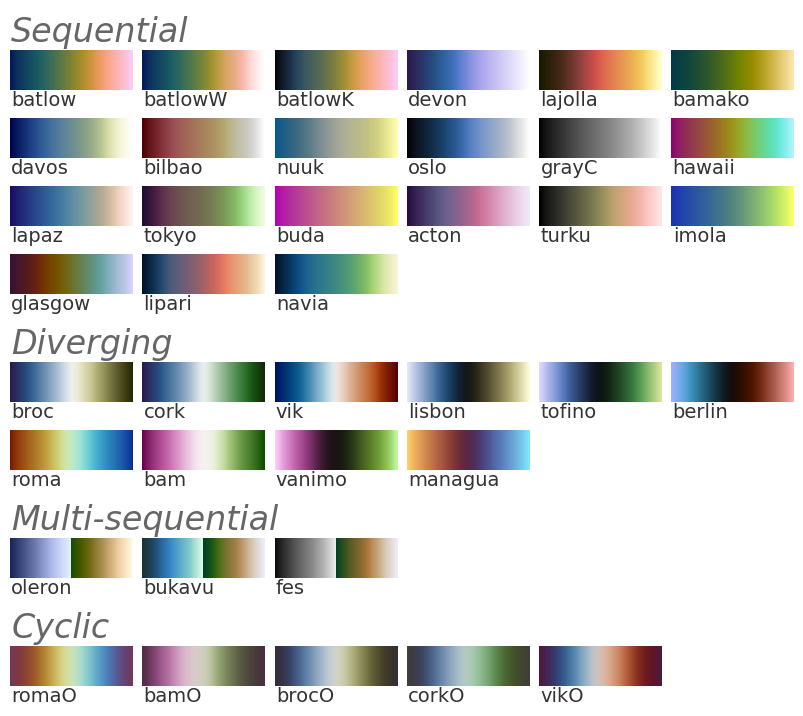

In [2]:
cmc.show_cmaps()

In [5]:
print(900000/(25*25))

1440.0


In [8]:
# print(f'{1e+4:.0e}')
# f'{np.pi:.1e}'
# print(1e+4)

lambdas = np.logspace(-6,11,num=6)
print(lambdas[::3])

for l in lambdas:
    print(f'{l:.0e}')

[1.00000000e-06 1.58489319e+04]
1e-06
3e-03
6e+00
2e+04
4e+07
1e+11


In [ ]:
num_neurons_per_layer=np.random.randint(7,10)
print(num_neurons_per_layer)

l1_lambda = np.random.randint

11


### L-curve analysis for smoothness reg tuning

5 models


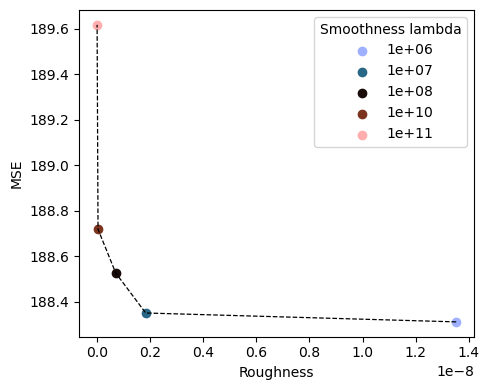

In [13]:
lambdas = np.logspace(-8,11,num=20)

lambdas_true = []
mses = []
smoothness = []
validations = []

for l in lambdas:
    # folder_formats = [
    #     f'models/reg_test_flawed/PINN_ext_smoothness_reg_{l:.0e}',
    #     f'models/reg_test_flawed/PINN_ext_smoothness_reg_{l:.0f}',
    #     f'models/reg_test_flawed/PINN_ext_smoothness_reg_{l}'
    # ]
    # for folder_name in folder_formats:
    #     try:
    #         mses.append(np.load(f'{folder_name}/training_history.npy')[-1])
    #         smoothness.append(np.load(f'{folder_name}/smoothness_history.npy')[-1])
    #         # validations.append(np.load(f'{folder_name}/val_loss_hist.npy')[-1])
    #         lambdas_true.append(l)
    #         break
    #     except:
    #         continue
    if l == 1e9:
        continue
    folder_name = f'models/PINN_ext_smoothness_reg_{l:.0e}'
    try:
        mses.append(np.load(f'{folder_name}/training_history.npy')[-1])
        smoothness.append(np.load(f'{folder_name}/smoothness_history.npy')[-1])
        lambdas_true.append(l)
    except:
        continue
    

print(len(mses), 'models')
cmap = cmc.berlin(np.linspace(0, 1, len(lambdas_true)))
plt.figure(figsize=(5,4))
plt.plot(smoothness, mses, color = 'k', linewidth = 0.9, linestyle = '--')
for i in range(len(lambdas_true)):
    plt.scatter(smoothness[i], mses[i], label=f'{lambdas_true[i]:.0e}', c=cmap[i])
plt.xlabel('Roughness')
plt.ylabel('MSE')
plt.legend(loc=1, ncols=1,title='Smoothness lambda')
plt.tight_layout()
plt.show()
plt.close()

### L-curve analysis for L1 penalty tuning

In [4]:
train_hist = np.load('models/PINN_ext_model_18/training_history.npy')
m, c = ut.slope(train_hist, 10)
print(f'Slope: {m}')

Slope: -0.003652411717773282


In [7]:
print(5e2)

500.0


6
[ True  True  True  True  True False  True]


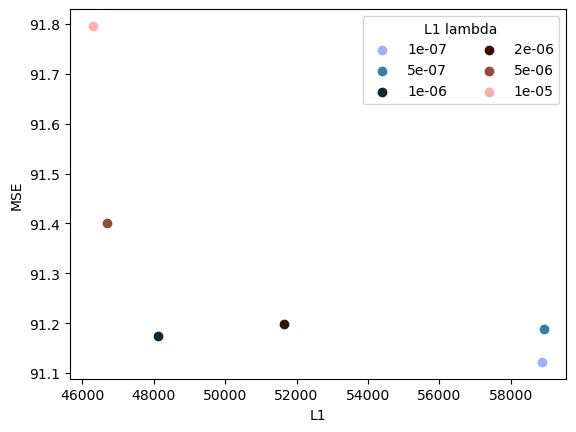

In [56]:
lambdas = [1e-7, 5e-7, 1e-6, 2e-6, 5e-6, 7e-6, 1e-5]
models =  [    27, 29, 19,   26,   23,   280, 21]
mses = []
l1s = []
for model in models:
    try:
        mses.append(np.load(f'models/PINN_ext_model_{model}/training_history.npy')[-1])
        l1s.append(np.load(f'models/PINN_ext_model_{model}/l1_history.npy')[-1])
    except:
        mses.append(None)
        l1s.append(None)

condition = np.array([i is not None for i in mses])
print(sum(condition))
print(condition)
mses = np.array(mses)[condition]
l1s = np.array(l1s)[condition]
lambdas = np.array(lambdas)[condition]

cmap = cmc.berlin(np.linspace(0, 1, len(lambdas)))
# plt.plot(l1s, mses, color = 'k')
for i in range(len(mses)):
    plt.scatter(l1s[i], mses[i], label=lambdas[i], c=cmap[i])
plt.xlabel('L1')
plt.ylabel('MSE')
plt.legend(loc=1, ncols=2,title='L1 lambda')
plt.show()
plt.close()

### ensemble of models

In [23]:
tensor_a = torch.tensor([[1,2,3],[4,5,6]], dtype=torch.float32)
tensor_b = tensor_a.clone()
tensor_c = tensor_a.clone()
# tensor_b = torch.tensor([4,5,6], dtype=torch.float32)
# tensor_c = torch.tensor([7,8,9], dtype=torch.float32)
tensor_list = torch.vstack((tensor_a,tensor_b))
tensor_list = torch.vstack((tensor_list,tensor_c))
print(tensor_list)
tensor_mean = torch.mean(tensor_list, dim = 0)
print(tensor_mean)


tensor([[1., 2., 3.],
        [4., 5., 6.],
        [1., 2., 3.],
        [4., 5., 6.],
        [1., 2., 3.],
        [4., 5., 6.]])
tensor([2.5000, 3.5000, 4.5000])


In [5]:
models = [1,3,6,10,11,14]
epochs = [715,9325,"last","last","last","last"]
for model,epoch in zip(models,epochs):
    df = pd.read_csv(f'predictions/PINN_MSO_model{model}_epoch{epoch}_150km_fibonacci.csv')
    if model == 1:
        df_sum = df.copy()
    else:
        df_sum[['Bx','By','Bz','Jx','Jy','Jz','Br','Bt','Bp','Jr','Jt','Jp']] += df[['Bx','By','Bz','Jx','Jy','Jz','Br','Bt','Bp','Jr','Jt','Jp']]

df_sum[['Bx','By','Bz','Jx','Jy','Jz','Br','Bt','Bp','Jr','Jt','Jp']] /= len(models)

df_sum.to_csv('predictions/PINN_MSO_150km_models_1_3_6_10_11_14.csv')

### Hyperparameter tuning / training analysis

In [4]:
print(np.arange(1,2))

[1]


In [3]:
num_hidden_layers=3,
num_neurons_per_layer=32,
num_neurons = np.ones(num_hidden_layers, dtype=int)*num_neurons_per_layer
print(num_neurons)

[32 32 32]


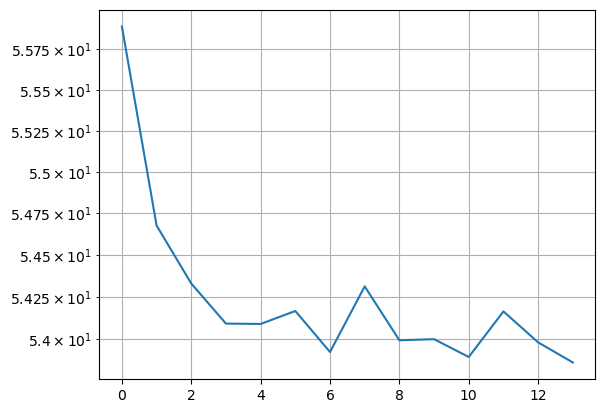

In [3]:
bs = 3
train_hist = np.load(f'models/PINN_ext_bootstrap_{bs}/val_loss_hist.npy')
plt.plot(train_hist)
plt.yscale('log')
plt.grid(axis='both',which='both')
# plt.ylim([train_hist[0],6.02933*1e1])
# plt.ylim([60.2,60.4])

### Calculator

In [13]:
num_neurons = 64
num_inputs = 4
num_params = num_inputs*num_neurons + num_neurons + num_neurons*3 + 3
print(f'Number of parameters in NN {num_params}')
print(f'SH equivalent number of degrees {np.sqrt(num_params)-1}')

Number of parameters in NN 515
SH equivalent number of degrees 21.693611435820433


In [31]:
num_neurons = 64
num_inputs = 3
num_params = num_inputs*num_neurons + num_neurons + num_neurons*3 + 3
print(f'Number of parameters in NN {num_params}')
print(f'SH equivalent number of degrees {np.sqrt(num_params)-1}')

Number of parameters in NN 451
SH equivalent number of degrees 20.236760581595302


In [23]:
input = torch.load('data/position_mso.pt')
print(f'input mean = {torch.mean(input)}, std = {torch.std(input)}')
alt = torch.load('data/position_pc.pt')[:,0]
alt = alt.unsqueeze(1)
print(f'Alt mean = {torch.mean(alt)}, std = {torch.std(alt)}')
crustal_field_mso = torch.load('data/crustal_field_mso.pt')
observation_mso = torch.load('data/observation_mso.pt')
target = observation_mso - crustal_field_mso
print(f'Target mean = {torch.mean(target)} std = {torch.std(target)}')

input mean = 6.006184101104736, std = 3967.865478515625
Alt mean = 3234.762451171875, std = 1828.796875
Target mean = 0.08023015409708023 std = 7.764457702636719


In [26]:
col = 2
print(f'input mean = {torch.mean(input[:,col])}, std = {torch.std(input[:,col])}')

input mean = 71.04672241210938, std = 4517.708984375


In [29]:
a = np.arange(10)
print(a)
print(a[:3])

[0 1 2 3 4 5 6 7 8 9]
[0 1 2]


In [ ]:
#weekly cost:
gaswerk = 11.20
# commute = 6.40*2
weekend_trip = 30#(30+60+50)/3
week_costs = gaswerk  + weekend_trip
year_costs = week_costs * 52.1 + 800
print("yearly costs (CHF): ", year_costs)

In [ ]:
print("Hello, World!")

### File conversion testing

In [12]:
model_params = np.load('models/TEST_PINN_ext_model_8/model_params.npy', allow_pickle=True).item()
print(model_params['alt_std'])

182.8816375732422


In [4]:
crustal_field_mso = torch.load('data/crustal_field_mso.pt')
observation_mso = torch.load('data/observation_mso.pt')
target = observation_mso - crustal_field_mso
print(len(target))
# print('Min and max of target: ', torch.min(target), torch.max(target))
# print('Mean and std of target: ', torch.mean(target), torch.std(target))
# randomly downsample target to compute quantiles faster
# target_downsampled = target[torch.randperm(target.size(0))[:10000]]
# print('q1, median, q3 of target: ', torch.quantile(target_downsampled,0.25), torch.median(target_downsampled), torch.quantile(target_downsampled,0.75))
# print('IQR*1.5: ', 1.5*(torch.quantile(target_downsampled,0.75)-torch.quantile(target_downsampled,0.25)))

condition = (target <= 30) & (target >= -30)
condition = torch.any(condition, dim=1)
target = target[condition]
print(len(target))


304278321
304074925


In [9]:
print(0.25*3393.5)

848.375


In [3]:
input_1 = torch.load('data/position_mso_spherical.pt')
alt_1 = input_1[:,0].unsqueeze(1)
# input_2 = torch.load('data/position_pc.pt')
# alt_2 = input_2[:,0].unsqueeze(1)
# print(torch.sum(abs(alt_1-alt_2)))
id = np.random.randint(len(alt_1),size = 100000)
alt_1 = alt_1[id]
print(max(alt_1))

tensor([6494.9102])


In [6]:
input = torch.load('data/position_mso.pt')
n = len(input)
alt = torch.load('data/position_pc.pt')[:,0]
condition = alt <= 600 #km, only low altitude!
input = input[condition]
alt = alt[condition]

print(f'Data size : {len(input)*100/n:.2f} %')
print(f'Mean value : {torch.mean(input)}')
print(f'Standard deviation : {torch.std(input)}')
print('')
print(f'Mean alt : {torch.mean(alt)}')
print(f'Standard deviation alt : {torch.std(alt)}')


Data size : 11.67 %
Mean value : 17.585474014282227
Standard deviation : 2143.906982421875

Mean alt : 321.1726379394531
Standard deviation alt : 130.90621948242188


In [35]:
print(np.log(21730))

9.986449073250474


In [9]:
# df = pd.read_parquet('data/MAVEN_MSO_data.parquet', columns=['alt','SS lat','SS lon'])
# df['SS colat'] = 90 - df['SS lat']
# df['sin_colat'] = np.sin(np.radians(df['SS colat']))
# df['cos_colat'] = np.cos(np.radians(df['SS colat']))
# df['sin_lon'] = np.sin(np.radians(df['SS lon']))
# df['cos_lon'] = np.cos(np.radians(df['SS lon']))
# df = df.drop(columns=['SS lat','SS lon','SS colat'])
# print(df.head())
# input_spherical = torch.tensor(df.values, dtype=torch.float32)
input_spherical = torch.load('data/position_mso_spherical.pt')
a = torch.tensor([1,2,3,4,5], dtype=torch.float32)
b = input_spherical - a


In [16]:
print(torch.mean(alt))

tensor(3234.7625)


In [ ]:
# test position file
position = torch.load('data/position_pc.pt')
position_10000_random_picks = position[torch.randperm(position.size(0))[:10000]]
print(min(position_10000_random_picks[:, 0]), max(position_10000_random_picks[:, 0]))
print(min(position_10000_random_picks[:, 1]), max(position_10000_random_picks[:, 1]))
print(min(position_10000_random_picks[:, 2]), max(position_10000_random_picks[:, 2]))

In [ ]:
# compare crustal field from L19 and D25 (only scalar)
df = dc.format_sample()
df = df[['BL PC Bx','BL PC By','BL PC Bz']].values
crustal_field_pc = torch.load('data/crustal_field_pc.pt')
crustal_field_pc = crustal_field_pc[:len(df)]
df = torch.tensor(df, dtype=torch.float32)
B_l19 = np.sqrt(df[:,0]**2 + df[:,1]**2 + df[:,2]**2)
B_D25 = np.sqrt(crustal_field_pc[:,0]**2 + crustal_field_pc[:,1]**2 + crustal_field_pc[:,2]**2)
mse = torch.mean((B_l19 - B_D25)**2)
print("MSE crustal field (nT^2): ", mse.item())

In [ ]:
df = dc.format_sample()
df = df[['BL SS Bx','BL SS By','BL SS Bz']].values
crustal_field_mso = torch.load('data/crustal_field_mso.pt')
crustal_field_mso = crustal_field_mso[:len(df)]
df = torch.tensor(df, dtype=torch.float32)

mse = torch.mean((crustal_field_mso-df)**2)
print("MSE crustal field (nT^2): ", mse.item())

### Curl tests

#### 2D curl in cartesian coordinates

In [ ]:
x0 = np.arange(-10, 10, 1.0)
y0 = x0.copy()
X,Y = np.meshgrid(x0, y0)
x,y = X.ravel(), Y.ravel()
plt.figure()
plt.quiver(X,Y,Y,-X)
plt.show()


In [15]:
def tensor(t):
    return torch.tensor(t,dtype = torch.float32)


Input = torch.stack((tensor(x), tensor(y) ), dim=1)
Input = torch.tensor(Input,requires_grad=True)
Output1 = torch.zeros_like(Input)
Output1[:,0] = Input[:,1]
Output1[:,1] = -Input[:,0]
# gradient = torch.ones_like(Input)
Output1.sum().backward()
print(Input.grad.shape)

curl1 = Input.grad[:,0] - Input.grad[:,1]
print(torch.unique(curl1).item())

torch.Size([8000, 2])
-2.0


#### 3D curl in cartesian coordinates

In [ ]:
x0 = np.arange(-10, 10, 1.0)
y0 = x0.copy()
z0 = x0.copy()
X,Y,Z = np.meshgrid(x0, y0, z0)
x,y,z = X.ravel(), Y.ravel(), Z.ravel()
Input = torch.stack((tensor(x), tensor(y), tensor(z) ), dim=1)
Input.requires_grad=True

Output1 = torch.zeros_like(Input)
Output1[:,0] = Input[:,1] ** 3 - 9* Input[:,1]
Output1[:,1] = Input[:,0] ** 3 - 9* Input[:,0]
Output1[:,2] = 0


Output1[:,0].sum().backward(retain_graph=True)
dBx_dx = Input.grad[:,0].clone()
dBx_dy = Input.grad[:,1].clone()
dBx_dz = Input.grad[:,2].clone()

Input.grad.zero_()

Output1[:,1].sum().backward(retain_graph=True)
dBy_dx = Input.grad[:,0].clone()
dBy_dy = Input.grad[:,1].clone()
dBy_dz = Input.grad[:,2].clone()

Input.grad.zero_()

Output1[:,2].sum().backward(retain_graph=True)
dBz_dx = Input.grad[:,0].clone()
dBz_dy = Input.grad[:,1].clone()
dBz_dz = Input.grad[:,2].clone()

curl = torch.stack((dBz_dy - dBy_dz, dBx_dz - dBz_dx, dBy_dx - dBx_dy), dim=1)
cond = curl[:,2] > 0
print(curl[:,2][cond])

analytical_curl = torch.zeros_like(Input)
analytical_curl[:,0] = 0
analytical_curl[:,1] = 0
analytical_curl[:,2] = 3*Input[:,0]**2 - 3*Input[:,1]**2

print(analytical_curl[:,2][cond])



#### 3D curl(curl()) in cartesian coordinates

In [ ]:
def curl(Input, Output):
    
    Output[:,0].sum().backward(retain_graph=True)
    dBx_dx = Input.grad[:,0].clone()
    dBx_dy = Input.grad[:,1].clone()
    dBx_dz = Input.grad[:,2].clone()

    Input.grad.zero_()

    Output[:,1].sum().backward(retain_graph=True)
    dBy_dx = Input.grad[:,0].clone()
    dBy_dy = Input.grad[:,1].clone()
    dBy_dz = Input.grad[:,2].clone()

    Input.grad.zero_()

    Output[:,2].sum().backward(retain_graph=True)
    dBz_dx = Input.grad[:,0].clone()
    dBz_dy = Input.grad[:,1].clone()
    dBz_dz = Input.grad[:,2].clone()

    curl = torch.stack((dBz_dy - dBy_dz, dBx_dz - dBz_dx, dBy_dx - dBx_dy), dim=1)
    return curl



x0 = np.arange(-10, 10, 1.0)
y0 = x0.copy()
z0 = x0.copy()
X,Y,Z = np.meshgrid(x0, y0, z0)
x,y,z = X.ravel(), Y.ravel(), Z.ravel()
Input = torch.stack((tensor(x), tensor(y), tensor(z) ), dim=1)
Input.requires_grad = True
Output = torch.zeros_like(Input)
Output[:,0] = Input[:,1] ** 3 - 9* Input[:,1]
Output[:,1] = Input[:,0] ** 3 - 9* Input[:,0]
Output[:,2] = 0

curl1 = curl(Input, Output)

# checking results
tensors_combined = torch.concatenate((curl1,Input),dim=1)
tensors_combined = tensors_combined[cond].detach().numpy()
print(len(tensors_combined))
for i in range(len(tensors_combined)):
    if i == 0:
        print(tensors_combined[i])
        print(f'Analytical solution : {3*(tensors_combined[i,3]**2-tensors_combined[i,4]**2)}')
        
    elif (tensors_combined[i,2] == tensors_combined[i-1,2]):
        continue
    else:
        print(tensors_combined[i])
        print(f'Analytical solution : {3*(tensors_combined[i,3]**2-tensors_combined[i,4]**2)}')
        




In [22]:
def curl_differentiable(Input, Output):
    """
    Compute curl while maintaining computational graph for higher-order derivatives
    """
    # Use torch.autograd.grad instead of .backward() to maintain graph
    
    # Compute all partial derivatives using the same logic as the working version
    # ∂Bx/∂(x,y,z)

    grad_Bx = torch.autograd.grad(Output[:,0].sum(), Input, create_graph=True, retain_graph=True)[0]
    dBx_dx, dBx_dy, dBx_dz = grad_Bx[:,0], grad_Bx[:,1], grad_Bx[:,2]
    
    # ∂By/∂(x,y,z)  
    grad_By = torch.autograd.grad(Output[:,1].sum(), Input, create_graph=True, retain_graph=True)[0]
    dBy_dx, dBy_dy, dBy_dz = grad_By[:,0], grad_By[:,1], grad_By[:,2]
    
    # ∂Bz/∂(x,y,z)
    grad_Bz = torch.autograd.grad(Output[:,2].sum(), Input, create_graph=True, retain_graph=True)[0] 
    dBz_dx, dBz_dy, dBz_dz = grad_Bz[:,0], grad_Bz[:,1], grad_Bz[:,2]
    
    # Curl formula: (∂Bz/∂y - ∂By/∂z, ∂Bx/∂z - ∂Bz/∂x, ∂By/∂x - ∂Bx/∂y)
    curl_x = dBz_dy - dBy_dz
    curl_y = dBx_dz - dBz_dx  
    curl_z = dBy_dx - dBx_dy
    
    return torch.stack((curl_x, curl_y, curl_z), dim=1)

# Test and compare both versions
x0 = np.arange(-10, 10, 1.0)
y0 = x0.copy()
z0 = x0.copy()
X,Y,Z = np.meshgrid(x0, y0, z0)
x,y,z = X.ravel(), Y.ravel(), Z.ravel()
Input_new = torch.stack((tensor(x), tensor(y), tensor(z)), dim=1)
Input_new.requires_grad_(True)

Output_new = torch.zeros_like(Input_new)
Output_new[:,0] = Input_new[:,1] ** 3 - 9* Input_new[:,1]
Output_new[:,1] = Input_new[:,0] ** 3 - 9* Input_new[:,0]  
Output_new[:,2] = 0

print("Computing curl with differentiable version...")
curl1_diff = curl_differentiable(Input_new, Output_new)
# check_result(curl1_diff, Input_new)

curl2_diff = curl_differentiable(Input_new, curl1_diff)







tensors_combined = torch.concatenate((curl2_diff,Input),dim=1)
tensors_combined = tensors_combined.detach().numpy()
print(len(tensors_combined))
for i in range(len(tensors_combined)):
    if i == 0:
        print(tensors_combined[i])
        print(f'Analytical solution : x = {-6*tensors_combined[i,4]}, y = {-6*tensors_combined[i,3]}')
    elif (tensors_combined[i,0:2] == tensors_combined[i-1,0:2]).all():
        continue
    else:
        print(tensors_combined[i])
        print(f'Analytical solution : x = {-6*tensors_combined[i,4]}, y = {-6*tensors_combined[i,3]}')


Computing curl with differentiable version...
8000
[ 60.  60.   0. -10. -10.]
Analytical solution : x = 60.0, y = 60.0
[ 60.  54.   0.  -9. -10.]
Analytical solution : x = 60.0, y = 54.0
[ 60.  48.   0.  -8. -10.]
Analytical solution : x = 60.0, y = 48.0
[ 60.  42.   0.  -7. -10.]
Analytical solution : x = 60.0, y = 42.0
[ 60.  36.   0.  -6. -10.]
Analytical solution : x = 60.0, y = 36.0
[ 60.  30.   0.  -5. -10.]
Analytical solution : x = 60.0, y = 30.0
[ 60.  24.   0.  -4. -10.]
Analytical solution : x = 60.0, y = 24.0
[ 60.  18.   0.  -3. -10.]
Analytical solution : x = 60.0, y = 18.0
[ 60.  12.   0.  -2. -10.]
Analytical solution : x = 60.0, y = 12.0
[ 60.   6.   0.  -1. -10.]
Analytical solution : x = 60.0, y = 6.0
[ 60.   0.   0.   0. -10.]
Analytical solution : x = 60.0, y = -0.0
[ 60.  -6.   0.   1. -10.]
Analytical solution : x = 60.0, y = -6.0
[ 60. -12.   0.   2. -10.]
Analytical solution : x = 60.0, y = -12.0
[ 60. -18.   0.   3. -10.]
Analytical solution : x = 60.0, y = -1